## Backward Calculation of Implied Probabilities - Start: Aug 2024

In [1]:
import pandas as pd
import numpy as np

cme_aug_2024 = pd.read_csv("../../data/raw/CME/CME_AUG_2024.csv")
cme_aug_2024 = cme_aug_2024.reset_index(drop = True)
cme_aug_2024["time"] = pd.to_datetime(cme_aug_2024["time"],unit="s") 

In [2]:
cme_aug_2024

,time,open,high,low,close,Volume
0,2024-04-07 22:00:00,94.900,94.900,94.900,94.900,40
1,2024-04-07 22:01:00,94.895,94.895,94.895,94.895,31
2,2024-04-07 22:02:00,94.895,94.895,94.895,94.895,59
3,2024-04-07 22:03:00,94.895,94.895,94.895,94.895,4
4,2024-04-07 22:05:00,94.895,94.895,94.895,94.895,370
...,...,...,...,...,...,...
21117,2024-08-30 19:48:00,94.670,94.670,94.670,94.670,16
21118,2024-08-30 19:50:00,94.670,94.670,94.670,94.670,13
21119,2024-08-30 20:18:00,94.670,94.670,94.670,94.670,2
21120,2024-08-30 20:49:00,94.670,94.670,94.670,94.670,16


## CME End: Jul 2024

In [3]:
cme_jul_2024 = pd.read_csv("../../data/raw/CME/CME_JUL_2024.csv")
cme_jul_2024 = cme_jul_2024.reset_index(drop = True)
cme_jul_2024["time"] = pd.to_datetime(cme_jul_2024["time"],unit="s") 

In [4]:
cme_jul_2024

,time,open,high,low,close,Volume
0,2024-02-04 23:00:00,95.125,95.125,95.115,95.115,71
1,2024-02-04 23:01:00,95.115,95.115,95.115,95.115,1
2,2024-02-04 23:03:00,95.105,95.105,95.105,95.105,1
3,2024-02-04 23:12:00,95.105,95.105,95.105,95.105,1
4,2024-02-04 23:18:00,95.105,95.105,95.105,95.105,1
...,...,...,...,...,...,...
21113,2024-07-31 20:54:00,94.670,94.670,94.670,94.670,1
21114,2024-07-31 20:55:00,94.670,94.670,94.670,94.670,6
21115,2024-07-31 20:57:00,94.670,94.670,94.670,94.670,2
21116,2024-07-31 20:58:00,94.670,94.670,94.670,94.670,3


## Merge

In [5]:
aug = cme_aug_2024.copy()
aug["time"] = pd.to_datetime(aug["time"], unit="s")

if aug["time"].dt.tz is None:
    aug["time"] = aug["time"].dt.tz_localize("UTC")
else:
    aug["time"] = aug["time"].dt.tz_convert("UTC")

aug = aug.sort_values("time").set_index("time")
aug = aug.add_suffix("_aug_2024")

jul = cme_jul_2024.copy()
jul["time"] = pd.to_datetime(jul["time"], unit="s")

if jul["time"].dt.tz is None:
    jul["time"] = jul["time"].dt.tz_localize("UTC")
else:
    jul["time"] = jul["time"].dt.tz_convert("UTC")

jul = jul.sort_values("time").set_index("time")
jul = jul.add_suffix("_jul_2024")

In [6]:
final_df = aug.join(jul, how="left")

In [7]:
final_df = final_df.dropna()

In [8]:
final_df = final_df.reset_index()

In [9]:
final_df

,time,open_aug_2024,high_aug_2024,low_aug_2024,close_aug_2024,Volume_aug_2024,open_jul_2024,high_jul_2024,low_jul_2024,close_jul_2024,Volume_jul_2024
0,2024-04-07 22:00:00+00:00,94.9000,94.9000,94.900,94.900,40,94.805,94.805,94.805,94.805,35.0
1,2024-04-07 22:02:00+00:00,94.8950,94.8950,94.895,94.895,59,94.800,94.800,94.800,94.800,71.0
2,2024-04-07 22:05:00+00:00,94.8950,94.8950,94.895,94.895,370,94.800,94.805,94.800,94.805,392.0
3,2024-04-07 22:11:00+00:00,94.8950,94.8950,94.895,94.895,13,94.805,94.805,94.805,94.805,100.0
4,2024-04-07 22:17:00+00:00,94.8950,94.8950,94.895,94.895,88,94.805,94.805,94.805,94.805,125.0
...,...,...,...,...,...,...,...,...,...,...,...
5444,2024-07-31 20:25:00+00:00,94.6750,94.6750,94.675,94.675,122,94.670,94.670,94.670,94.670,1.0
5445,2024-07-31 20:40:00+00:00,94.6750,94.6750,94.675,94.675,1000,94.670,94.670,94.670,94.670,7.0
5446,2024-07-31 20:55:00+00:00,94.6775,94.6775,94.675,94.675,502,94.670,94.670,94.670,94.670,6.0
5447,2024-07-31 20:58:00+00:00,94.6750,94.6750,94.675,94.675,77,94.670,94.670,94.670,94.670,3.0


## Calculate Implied Probabilities

In [10]:
meeting_day = 31
days_in_july = 31

N = meeting_day           
M = days_in_july - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_jul"] = 100 - final_df["close_jul_2024"]
imp_df["effr_avg_aug"] = 100 - final_df["close_aug_2024"]

imp_df["effr_start_aug"] = imp_df["effr_avg_aug"]
imp_df["effr_end_jul"] = imp_df["effr_start_aug"]
imp_df["volume"] = final_df["Volume_jul_2024"]


In [11]:
imp_df["effr_start_jul"] = (
    imp_df["effr_avg_jul"] - (M / (N + M)) * imp_df["effr_end_jul"]
) / (N / (N + M))

In [12]:
imp_df["delta_effr"] = imp_df["effr_end_jul"] - imp_df["effr_start_jul"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]

states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [13]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

In [14]:
imp_df

,time,effr_avg_jul,effr_avg_aug,effr_start_aug,effr_end_jul,volume,effr_start_jul,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2024-04-07 22:00:00+00:00,5.195,5.100,5.100,5.100,35.0,5.195,-0.095,-0.38,-1.0,0.62,0.0,0.0,0.0,0.38,0.62,0.0,0.0,0.0,0.0
1,2024-04-07 22:02:00+00:00,5.200,5.105,5.105,5.105,71.0,5.200,-0.095,-0.38,-1.0,0.62,0.0,0.0,0.0,0.38,0.62,0.0,0.0,0.0,0.0
2,2024-04-07 22:05:00+00:00,5.195,5.105,5.105,5.105,392.0,5.195,-0.090,-0.36,-1.0,0.64,0.0,0.0,0.0,0.36,0.64,0.0,0.0,0.0,0.0
3,2024-04-07 22:11:00+00:00,5.195,5.105,5.105,5.105,100.0,5.195,-0.090,-0.36,-1.0,0.64,0.0,0.0,0.0,0.36,0.64,0.0,0.0,0.0,0.0
4,2024-04-07 22:17:00+00:00,5.195,5.105,5.105,5.105,125.0,5.195,-0.090,-0.36,-1.0,0.64,0.0,0.0,0.0,0.36,0.64,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5444,2024-07-31 20:25:00+00:00,5.330,5.325,5.325,5.325,1.0,5.330,-0.005,-0.02,-1.0,0.98,0.0,0.0,0.0,0.02,0.98,0.0,0.0,0.0,0.0
5445,2024-07-31 20:40:00+00:00,5.330,5.325,5.325,5.325,7.0,5.330,-0.005,-0.02,-1.0,0.98,0.0,0.0,0.0,0.02,0.98,0.0,0.0,0.0,0.0
5446,2024-07-31 20:55:00+00:00,5.330,5.325,5.325,5.325,6.0,5.330,-0.005,-0.02,-1.0,0.98,0.0,0.0,0.0,0.02,0.98,0.0,0.0,0.0,0.0
5447,2024-07-31 20:58:00+00:00,5.330,5.325,5.325,5.325,3.0,5.330,-0.005,-0.02,-1.0,0.98,0.0,0.0,0.0,0.02,0.98,0.0,0.0,0.0,0.0


## Calculating Implied Probabilities for June 2024

In [15]:
cme_jun_2024 = pd.read_csv("../../data/raw/CME/CME_JUN_2024.csv")
cme_jun_2024 = cme_jun_2024.reset_index(drop = True)
cme_jun_2024["time"] = pd.to_datetime(cme_jun_2024["time"],unit="s") 

In [16]:
cme_jun_2024

,time,open,high,low,close,Volume
0,2023-12-25 23:00:00,95.3700,95.3700,95.3700,95.3700,1
1,2023-12-26 00:29:00,95.3650,95.3650,95.3650,95.3650,2
2,2023-12-26 03:34:00,95.3650,95.3650,95.3650,95.3650,1
3,2023-12-26 07:47:00,95.3600,95.3600,95.3600,95.3600,5
4,2023-12-26 07:48:00,95.3600,95.3600,95.3600,95.3600,2
...,...,...,...,...,...,...
20229,2024-06-28 20:00:00,94.6700,94.6700,94.6700,94.6700,4
20230,2024-06-28 20:05:00,94.6700,94.6700,94.6700,94.6700,8
20231,2024-06-28 20:40:00,94.6700,94.6700,94.6700,94.6700,182
20232,2024-06-28 20:46:00,94.6675,94.6675,94.6675,94.6675,91


## Merge June and July

In [17]:
jul = imp_df[["time","effr_start_jul"]].copy()
jul = jul.sort_values("time").set_index("time")

jun = cme_jun_2024.copy()
jun["time"] = pd.to_datetime(jun["time"], unit="s")

if jun["time"].dt.tz is None:
    jun["time"] = jun["time"].dt.tz_localize("UTC")
else:
    jun["time"] = jun["time"].dt.tz_convert("UTC")

jun = jun.sort_values("time").set_index("time")
jun = jun.add_suffix("_jun_2024")

In [18]:
jul_aligned = jul.reindex(jun.index, method="ffill")


final_df = pd.concat([jun, jul_aligned ], axis=1)
final_df = final_df.reset_index()

In [19]:
final_df

,time,open_jun_2024,high_jun_2024,low_jun_2024,close_jun_2024,Volume_jun_2024,effr_start_jul
0,2023-12-25 23:00:00+00:00,95.3700,95.3700,95.3700,95.3700,1,NaN
1,2023-12-26 00:29:00+00:00,95.3650,95.3650,95.3650,95.3650,2,NaN
2,2023-12-26 03:34:00+00:00,95.3650,95.3650,95.3650,95.3650,1,NaN
3,2023-12-26 07:47:00+00:00,95.3600,95.3600,95.3600,95.3600,5,NaN
4,2023-12-26 07:48:00+00:00,95.3600,95.3600,95.3600,95.3600,2,NaN
...,...,...,...,...,...,...,...
20229,2024-06-28 20:00:00+00:00,94.6700,94.6700,94.6700,94.6700,4,5.325
20230,2024-06-28 20:05:00+00:00,94.6700,94.6700,94.6700,94.6700,8,5.325
20231,2024-06-28 20:40:00+00:00,94.6700,94.6700,94.6700,94.6700,182,5.325
20232,2024-06-28 20:46:00+00:00,94.6675,94.6675,94.6675,94.6675,91,5.325


## IMP rates calculation

In [20]:
meeting_day = 12
days_in_june = 30

N = meeting_day           
M = days_in_june - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_jun"] = 100 - final_df["close_jun_2024"]

imp_df["effr_end_jun"] = final_df["effr_start_jul"]
imp_df["volume"] = final_df["Volume_jun_2024"]


In [21]:
imp_df = imp_df.dropna()

In [22]:
imp_df["effr_start_jun"] = (
    imp_df["effr_avg_jun"] - (M / (N + M)) * imp_df["effr_end_jun"]
) / (N / (N + M))

In [23]:
imp_df["delta_effr"] = imp_df["effr_end_jun"] - imp_df["effr_start_jun"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]

states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [24]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

In [25]:
imp_df

,time,effr_avg_jun,effr_end_jun,volume,effr_start_jun,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
13695,2024-04-07 22:00:00+00:00,5.2450,5.195,24,5.32000,-0.12500,-0.500,-1.0,0.500,0.0,0.0,0.0,0.500,0.500,0.0,0.0,0.0,0.0
13696,2024-04-07 22:01:00+00:00,5.2450,5.195,3,5.32000,-0.12500,-0.500,-1.0,0.500,0.0,0.0,0.0,0.500,0.500,0.0,0.0,0.0,0.0
13697,2024-04-07 22:03:00+00:00,5.2450,5.200,8,5.31250,-0.11250,-0.450,-1.0,0.550,0.0,0.0,0.0,0.450,0.550,0.0,0.0,0.0,0.0
13698,2024-04-07 22:08:00+00:00,5.2450,5.195,74,5.32000,-0.12500,-0.500,-1.0,0.500,0.0,0.0,0.0,0.500,0.500,0.0,0.0,0.0,0.0
13699,2024-04-08 00:26:00+00:00,5.2450,5.195,5,5.32000,-0.12500,-0.500,-1.0,0.500,0.0,0.0,0.0,0.500,0.500,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20229,2024-06-28 20:00:00+00:00,5.3300,5.325,4,5.33750,-0.01250,-0.050,-1.0,0.950,0.0,0.0,0.0,0.050,0.950,0.0,0.0,0.0,0.0
20230,2024-06-28 20:05:00+00:00,5.3300,5.325,8,5.33750,-0.01250,-0.050,-1.0,0.950,0.0,0.0,0.0,0.050,0.950,0.0,0.0,0.0,0.0
20231,2024-06-28 20:40:00+00:00,5.3300,5.325,182,5.33750,-0.01250,-0.050,-1.0,0.950,0.0,0.0,0.0,0.050,0.950,0.0,0.0,0.0,0.0
20232,2024-06-28 20:46:00+00:00,5.3325,5.325,91,5.34375,-0.01875,-0.075,-1.0,0.925,0.0,0.0,0.0,0.075,0.925,0.0,0.0,0.0,0.0


## Filter Based on Decision Date


In [26]:
fomc_2024_utc = {
    "January 2024": pd.Timestamp("2024-01-31 19:00:00", tz="UTC"),   
    "March 2024": pd.Timestamp("2024-03-20 18:00:00", tz="UTC"),     
    "May 2024": pd.Timestamp("2024-05-01 18:00:00", tz="UTC"),       
    "June 2024": pd.Timestamp("2024-06-12 18:00:00", tz="UTC"),      
    "July 2024": pd.Timestamp("2024-07-31 18:00:00", tz="UTC"),      
    "novtember 2024": pd.Timestamp("2024-09-18 18:00:00", tz="UTC"), 
    "November 2024": pd.Timestamp("2024-11-07 19:00:00", tz="UTC"),  
    "December 2024": pd.Timestamp("2024-12-18 19:00:00", tz="UTC"),  
}

In [27]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [28]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2024_utc)

In [29]:
imp_df_fil

,time,effr_avg_jun,effr_end_jun,volume,effr_start_jun,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
13695,2024-04-07 22:00:00+00:00,5.245,5.195,24,5.3200,-1.250000e-01,-5.000000e-01,-1.0,5.000000e-01,0.0,0.0,0.0,0.50,0.50,0.000000e+00,0.0,0.0,0.0
13696,2024-04-07 22:01:00+00:00,5.245,5.195,3,5.3200,-1.250000e-01,-5.000000e-01,-1.0,5.000000e-01,0.0,0.0,0.0,0.50,0.50,0.000000e+00,0.0,0.0,0.0
13697,2024-04-07 22:03:00+00:00,5.245,5.200,8,5.3125,-1.125000e-01,-4.500000e-01,-1.0,5.500000e-01,0.0,0.0,0.0,0.45,0.55,0.000000e+00,0.0,0.0,0.0
13698,2024-04-07 22:08:00+00:00,5.245,5.195,74,5.3200,-1.250000e-01,-5.000000e-01,-1.0,5.000000e-01,0.0,0.0,0.0,0.50,0.50,0.000000e+00,0.0,0.0,0.0
13699,2024-04-08 00:26:00+00:00,5.245,5.195,5,5.3200,-1.250000e-01,-5.000000e-01,-1.0,5.000000e-01,0.0,0.0,0.0,0.50,0.50,0.000000e+00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19713,2024-06-12 17:46:00+00:00,5.330,5.330,65,5.3300,8.881784e-16,3.552714e-15,0.0,3.552714e-15,0.0,0.0,0.0,0.00,1.00,3.552714e-15,0.0,0.0,0.0
19714,2024-06-12 17:53:00+00:00,5.330,5.325,34,5.3375,-1.250000e-02,-5.000000e-02,-1.0,9.500000e-01,0.0,0.0,0.0,0.05,0.95,0.000000e+00,0.0,0.0,0.0
19715,2024-06-12 17:54:00+00:00,5.330,5.325,1,5.3375,-1.250000e-02,-5.000000e-02,-1.0,9.500000e-01,0.0,0.0,0.0,0.05,0.95,0.000000e+00,0.0,0.0,0.0
19716,2024-06-12 17:56:00+00:00,5.330,5.325,3,5.3375,-1.250000e-02,-5.000000e-02,-1.0,9.500000e-01,0.0,0.0,0.0,0.05,0.95,0.000000e+00,0.0,0.0,0.0


## Visualization

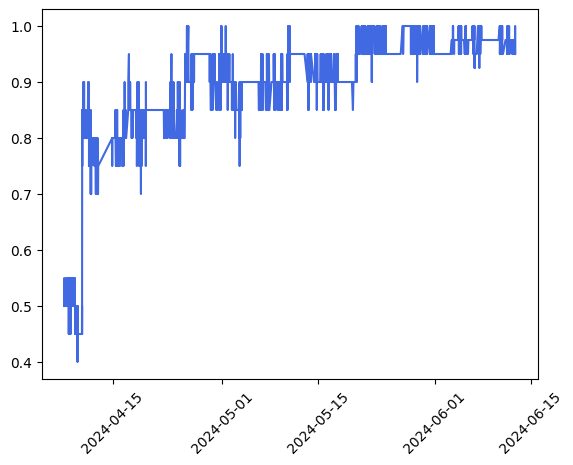

In [30]:
import matplotlib.pyplot as plt

plt.plot(imp_df_fil["time"],imp_df_fil['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()

## Export Data as CSV

In [31]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_JUN_2024.csv"
path = os.path.join(DATA_DIR, filename)
imp_df_fil.to_csv(path,index=False)